# DL063 生成模型评价与风险

此Notebook实际重训VAE与GAN各三种子。所有模型采用固定终点；控制分布明确标记。教学结果另存notebook_outputs，避免覆盖原outputs。

In [1]:
from pathlib import Path
import sys, json, numpy as np, torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    b=BytesIO(); fig.savefig(b,format='png',dpi=130,bbox_inches='tight')
    display(Image(data=b.getvalue())); plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '063'}


## 1 指标的分母与盲点
质量是全部生成点中落入有效域的比例。覆盖要求某模式有效计数至少占全部样本1%。坐标均值协方差相同并不意味着模式相同。

In [2]:
x=e.centers().astype(float)
a=np.pi/8;rot=np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]])
y=x@rot.T
print('rotated quality:',e.mode_metrics(y))
print('xy Gaussian feature distance:',e.gaussian_feature_distance(x,y))
print('angle features:',e.gaussian_feature_distance(x,y,'radial_angle'))

rotated quality: {'valid_fraction': 0.0, 'coverage': 0, 'counts': [0, 0, 0, 0, 0, 0, 0, 0], 'entropy': -0.0, 'distance_to_mode': 0.7803612780480276}
xy Gaussian feature distance: 3.851859888774472e-33
angle features: 2.2857141818289843


## 2 普通单元测试
同一文件还应在命令行使用python -O -m unittest -v test_experiment.py运行，确保验证不依赖assert语句。

In [3]:
import unittest, test_experiment
r=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not r.wasSuccessful(): raise RuntimeError('Tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 20 tests in 0.839s

OK


## 3 完整真实训练
三种子×两家族×4000轮。匹配主模型更新次数和真实批次数；GAN另含判别器更新，因此不声称FLOPs相等。

In [4]:
results=e.main(Path('notebook_outputs'),steps=4000)
for row in results['runs']:
    print(row['family'],row['seed'],row['metrics']['valid_fraction'],row['feature_distance']['xy'])

vae 11 {'valid_fraction': 0.710693359375, 'coverage': 8, 'counts': [369, 330, 421, 295, 485, 306, 417, 288], 'entropy': 2.0628718280483307, 'distance_to_mode': 0.28588980570009526}


vae 23 {'valid_fraction': 0.70654296875, 'coverage': 8, 'counts': [409, 313, 389, 331, 426, 352, 399, 275], 'entropy': 2.069945136321836, 'distance_to_mode': 0.2899624679293267}


vae 37 {'valid_fraction': 0.70458984375, 'coverage': 8, 'counts': [429, 243, 390, 284, 458, 279, 470, 333], 'entropy': 2.0530755092663284, 'distance_to_mode': 0.28997069199124037}


gan 11 {'valid_fraction': 0.740234375, 'coverage': 8, 'counts': [184, 491, 369, 448, 207, 492, 461, 380], 'entropy': 2.0287457320869997, 'distance_to_mode': 0.2237410785031239}


gan 23 {'valid_fraction': 0.765380859375, 'coverage': 8, 'counts': [401, 353, 286, 452, 517, 422, 285, 419], 'entropy': 2.060752076641493, 'distance_to_mode': 0.21720626853652575}


gan 37 {'valid_fraction': 0.767333984375, 'coverage': 8, 'counts': [374, 414, 160, 527, 432, 427, 390, 419], 'entropy': 2.04284889667949, 'distance_to_mode': 0.2142397688262774}


vae 11 0.710693359375 0.007939964388597192
vae 23 0.70654296875 0.00741170743848099
vae 37 0.70458984375 0.010818214291135029
gan 11 0.740234375 0.01784341569882901
gan 23 0.765380859375 0.013217996502770253
gan 37 0.767333984375 0.01632439040906946


## 4 看全部样本
以下固定种子11，画出4096点，不筛选漂亮点。VAE保留条件观测噪声。

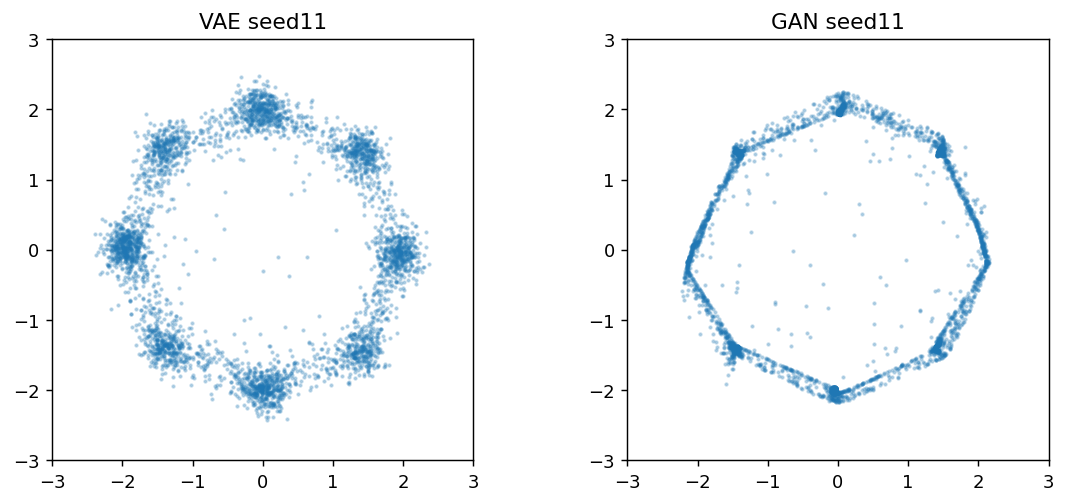

In [5]:
fig,axes=plt.subplots(1,2,figsize=(9,4))
for ax,family in zip(axes,['vae','gan']):
    x=np.load(f'notebook_outputs/{family}_seed11_samples.npz')['samples']
    ax.scatter(x[:,0],x[:,1],s=2,alpha=.25)
    ax.set(title=family.upper()+' seed11',xlim=(-3,3),ylim=(-3,3),aspect='equal')
fig.tight_layout();show(fig)

## 5 样本量改变估计值
两组来自同一个真实分布的独立样本，总体距离应为0；有限样本插件估计通常为正。误差线表示20次重复的标准差。

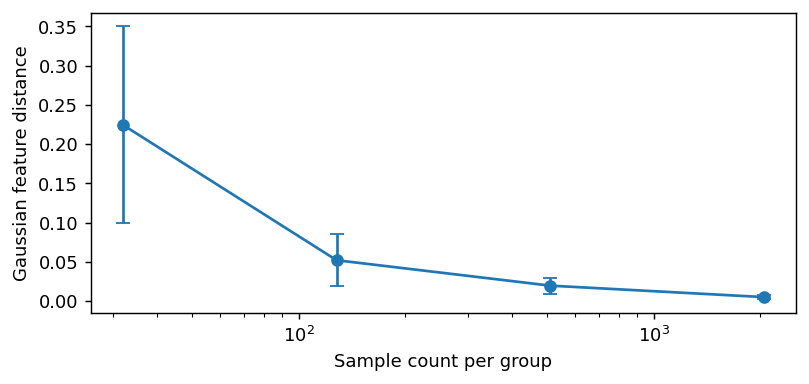

In [6]:
rows=results['sample_size_audit']
fig,ax=plt.subplots(figsize=(7,3))
ax.errorbar([r['n'] for r in rows],[r['mean'] for r in rows],yerr=[r['std'] for r in rows],marker='o',capsize=4)
ax.set(xscale='log',xlabel='Sample count per group',ylabel='Gaussian feature distance')
show(fig)

## 6 最近邻记忆审计
两个参考集大小相同。复制器质量和覆盖可以满分，但训练精确匹配率为1；这只是检测已知复制的阳性控制，不是证明网络具备或缺乏所有隐私风险。

In [7]:
for key,row in results['controls'].items(): print(key,row['audit'])
for row in results['runs']: print(row['family'],row['seed'],row['audit'])

oracle {'train_median': 0.009044379892534057, 'holdout_median': 0.008982485021978626, 'train_closer_fraction': 0.507080078125, 'exact_train_fraction': 0.0, 'exact_holdout_fraction': 0.0}
copier {'train_median': 0.0, 'holdout_median': 0.009151346478212235, 'train_closer_fraction': 1.0, 'exact_train_fraction': 1.0, 'exact_holdout_fraction': 0.0}
one_mode {'train_median': 0.007955334559766204, 'holdout_median': 0.0008166305672633037, 'train_closer_fraction': 0.0, 'exact_train_fraction': 0.0, 'exact_holdout_fraction': 0.0}
rotated_modes {'train_median': 0.5607844893565224, 'holdout_median': 0.5393261395634286, 'train_closer_fraction': 0.25, 'exact_train_fraction': 0.0, 'exact_holdout_fraction': 0.0}
vae 11 {'train_median': 0.04557257223441903, 'holdout_median': 0.04750818312087041, 'train_closer_fraction': 0.48681640625, 'exact_train_fraction': 0.0, 'exact_holdout_fraction': 0.0}
vae 23 {'train_median': 0.04862751256359798, 'holdout_median': 0.048280477231193, 'train_closer_fraction': 0.46

## 7 检查点复生
受限加载自己生成的权重，固定采样随机数，应逐元素重现保存样本。

In [8]:
for row in results['runs']:
    family,seed=row['family'],row['seed']
    c=torch.load(f'notebook_outputs/{family}_seed{seed}.pt',weights_only=True)
    m=e.VAE() if family=='vae' else e.Generator();m.load_state_dict(c['state_dict']);m.eval()
    sample,means=e.sample_model(m,family,c['sampling_seed'])
    stored=np.load(f'notebook_outputs/{family}_seed{seed}_samples.npz')
    np.testing.assert_array_equal(sample,stored['samples']);np.testing.assert_array_equal(means,stored['means'])
print('All six checkpoints reproduce both saved arrays exactly.')

All six checkpoints reproduce both saved arrays exactly.


## 结论练习
为什么本次坐标高斯距离偏好VAE，但有效比例偏好GAN？给出特征不充分、有限样本和模型差异的分别解释。该实验不能回答条件一致性、真实图像语义质量或严格隐私保证。